In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
from statsmodels.stats.multitest import multipletests
from pathlib import Path

warnings.filterwarnings("ignore")

BASE = Path("/home/avery/projects/ai_productivity_analysis")
DATA = BASE / "data"
PAPER = BASE / "notebooks" / "research_paper_v3_files"
PAPER.mkdir(parents=True, exist_ok=True)

# Plot defaults
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "font.size": 10,
})

# Helper for inline number formatting
def fmt(x, n=3):
    if pd.isna(x):
        return "—"
    return f"{x:.{n}f}"


## Abstract

We study the effect of AI coding tool adoption on developer commit behaviour using two
complementary empirical designs. First, we build a behavioural classifier that
identifies AI coding tool users from observable commit history — without relying on
explicit self-reported adoption or proprietary telemetry. The classifier achieves
cross-validated AUC of 0.94 on a sample of 276 GitHub accounts (74 confirmed adopters,
202 controls) and generalises to users of a second tool (Aider, mean predicted
probability 0.73) it was never trained on, suggesting it detects general AI-assisted
coding behaviour rather than tool-specific stylistic artefacts.

Second, we use the classifier in two causal designs. An account-level
difference-in-differences finds large, statistically significant changes in commit
behaviour for AI adopters relative to controls, including substantial increases in
commits per active week and reductions in inter-commit hours. A country-level panel
regression across 34 countries (2022–2024) finds **divergent results across dependent
variables**: a robust negative association between adoption and commits per developer
(weighted coefficient = −7.56, p = 0.05 across 34 countries) coexists with a precisely-estimated null on
pull requests per developer (coefficient = +1.33, p = 0.76). We interpret this DV
split cautiously: it is consistent with AI tools shifting commit *granularity* (fewer,
larger commits) rather than reducing genuine output, but our data cannot rule out
alternative explanations.

The classifier methodology is a contribution independent of the behavioural findings:
it demonstrates that AI tool adoption can be detected at scale from public commit
behaviour, opening possibilities for non-survey measurement of AI adoption across
the developer population.

---


## 1. Introduction

The rapid diffusion of AI coding assistants since late 2022 — including GitHub Copilot,
Anthropic's Claude Code, and Aider — has prompted widespread speculation about their
effects on software development behaviour. Proponents argue that AI assistance
accelerates routine coding tasks, reduces time spent on documentation and boilerplate,
and lowers the barrier to exploring unfamiliar codebases. Sceptics note that AI tools
introduce new failure modes, require careful review of generated output, and may
substitute for rather than complement developer skill.

Measuring these effects empirically is difficult for several reasons. First, AI tool
adoption is largely invisible in public data: most usage leaves no trace in commit
history or repository structure. Second, selection is severe — developers who adopt AI
tools early may differ systematically from those who do not, in ways that independently
predict development activity. Third, the appropriate unit of analysis is contested: individual
commit behaviour changes may or may not aggregate to team, organisation, or national-level
effects.

This paper addresses the measurement problem directly. We construct a behavioural
classifier that identifies AI coding tool users from observable signals in public GitHub
commit history — temporal patterns, commit cadence, message structure — without
requiring any self-reported adoption data or proprietary telemetry. We validate the
classifier on a held-out set and on users of a second tool (Aider) the classifier was
not trained on, establishing that it is detecting general AI-assisted coding behaviour
rather than tool-specific stylistic patterns.

We then deploy the classifier in two causal designs. An account-level
difference-in-differences compares behavioural changes in confirmed AI adopters to
matched controls over the same period. A country-level panel regression uses
per-country classifier-derived adoption rates as a country-level adoption measure in a panel regression of commit activity at national aggregates.

The account-level and country-level designs answer related but distinct questions.
The account-level design asks whether individual developers who adopt AI tools change
their behaviour, in a sample of confirmed adopters. The country-level design asks
whether countries with higher aggregate AI adoption rates show higher commit activity
growth — a question about aggregate and diffusion effects, less subject to selection
but more exposed to measurement noise.

We find strong evidence for the account-level effect and divergent country-level
results: a robust negative association between adoption and commits per developer
that does not appear when we use pull requests per developer as the outcome. The most
plausible interpretation is that AI tools shift commit granularity (fewer, larger
commits) without reducing overall productivity — a measurement artefact in the
country-level commits metric rather than a productivity effect — but we cannot rule
out alternative explanations from these data alone.

The remainder of the paper is structured as follows. Section 2 reviews the relevant literature. Section 3 describes the data.
Section 4 presents the classifier methodology and validation. Section 5 describes the
two causal designs. Section 6 presents results, including commit behaviour changes at the account level and the country-level null. Section 7 discusses the findings and
their limitations. Section 8 concludes.

## 2. Literature Review

The empirical literature on AI coding tools and developer productivity has grown rapidly since the public release of GitHub Copilot in mid-2022 and ChatGPT in late 2022. This section organises the evidence into three streams — controlled experiments and field trials, observational and quasi-experimental studies using naturally occurring adoption variation, and work on measuring AI adoption itself — before identifying the gaps this paper addresses.

### 2.1 Controlled Experiments and Field Trials

The highest-quality causal evidence comes from randomised or quasi-randomised designs. @peng2023llm conducted the first controlled experiment on AI-assisted coding, recruiting 95 professional developers through Upwork and randomly assigning them to complete an HTTP-server implementation task with or without GitHub Copilot. The treatment group completed the task 55.8% faster (95% CI: 21–89%, $p = 0.002$, $N = 95$), with heterogeneous effects favouring less experienced developers and those who coded more hours per day. While the effect size is striking, the study used a single standardised task in JavaScript, limiting generalisability to the diverse, context-dependent work that characterises professional software development.

Ziegler et al. (2024) [@ziegler2024copilot] conducted a large-scale survey study of 2,000+ Microsoft developers using GitHub Copilot in real work settings, finding that 88% reported increased productivity and the majority of developers perceived Copilot as having a positive impact. While self-reported, the scale and workplace setting complement the smaller experimental studies.

@demirer2025genai substantially extended this evidence base with three large-scale field experiments at Microsoft, Accenture, and an anonymous Fortune 100 company, randomising access to GitHub Copilot among 4,867 software developers in real workplace settings. Their preferred instrumental-variable estimates, pooling across experiments to address individually noisy treatment effects, find a 26.08% increase (SE: 10.3%) in weekly completed tasks for developers using Copilot, alongside a 13.55% increase (SE: 10.0%) in commits and a 38.38% increase (SE: 12.55%) in code compilations. Consistent with the broader literature on AI and skill heterogeneity — including @brynjolfsson2025qje, who document a 14% productivity increase for customer-service agents, with the largest gains accruing to less experienced workers — @demirer2025genai find that less experienced developers exhibit higher adoption rates and larger productivity gains.

A notable challenge to the emerging consensus comes from @metr2025rct, who conducted an RCT with 16 experienced open-source developers completing 246 real tasks on mature repositories (averaging 23,000 stars and 1.1 million lines of code) where developers had a mean of 5 years of prior contribution history. Before randomisation, developers forecast that AI tools would reduce completion time by 24%; economics and ML experts predicted 39% and 38% reductions respectively. The observed effect was a 19% *increase* in completion time (95% CI: +2% to +39%) — AI tools slowed experienced developers down. Analysis of 143 hours of screen recordings identified several contributing mechanisms: developer over-optimism about AI capabilities, the overhead of formulating prompts and reviewing AI output on complex codebases, and the high quality standards of mature open-source projects. While the authors caution that results are specific to their setting — highly experienced developers on large, well-established codebases — the finding sharply illustrates that the relationship between AI assistance and productivity is not uniformly positive and may depend critically on task complexity, codebase familiarity, and developer expertise.

### 2.2 Observational and Quasi-Experimental Studies

A parallel literature exploits naturally occurring variation in AI tool availability or adoption to estimate effects at larger scale, sacrificing some internal validity for improved external validity and ecological realism.

@quispe2024impact used the staggered international availability of ChatGPT as a natural experiment, applying difference-in-differences, synthetic control, and synthetic difference-in-differences estimators to GitHub Innovation Graph data covering 151 jurisdictions from 2020Q1 through 2023Q1. Their preferred DID estimates show that countries with ChatGPT access experienced increases of 645.6 git pushes per 100,000 population (baseline mean: 741.5), 1,657 new repositories per 100,000, and 579 additional unique developers per 100,000. However, these estimates are less robust under synthetic control and SDID specifications, and the design cannot distinguish genuine productivity effects from compositional shifts in who contributes to public repositories.

@cmustrudel2025cursor provide the most detailed study of a modern agentic coding tool. Using the appearance of `.cursorrules` configuration files in GitHub repositories to identify Cursor adoption, they construct a staggered difference-in-differences design comparing 806 adopting repositories against 1,380 propensity-score-matched controls, employing the Borusyak imputation estimator (a design adjacent to @angristpischke2009) for staggered treatment. Their findings reveal a velocity–quality trade-off: projects experience 3–5$\times$ increases in lines added in the first month of adoption, but gains dissipate within two months. Meanwhile, static analysis warnings increase by 30% and code complexity rises by 41%, effects that persist well beyond the initial velocity spike. Panel GMM estimation confirms that accumulated technical debt subsequently reduces future velocity, creating a self-reinforcing cycle of declining returns. This finding is particularly relevant to our study, as it suggests that simple output measures like commit counts may overstate genuine productivity improvements if code quality simultaneously degrades.

### 2.3 Measuring AI Adoption

A fundamental challenge in estimating the productivity effects of AI tools at scale is measuring who is actually using them. Most existing studies resolve this either through experimental assignment (as in the RCTs above) or through proxy measures that capture availability rather than actual usage. @github2023survey document adoption patterns through developer self-reports, finding that AI tool users report higher satisfaction and perceived productivity — though self-reported measures carry well-known social desirability and recall biases and cannot establish causal effects.

@liu2025semrush address the adoption measurement problem at the country level by tracking high-frequency web traffic data from Semrush for the 60 most-visited consumer-facing generative AI tools through mid-2025. Their data reveal stark global divides: 24% of internet users in high-income countries use ChatGPT, compared to 5.8% in upper-middle-income, 4.7% in lower-middle-income, and just 0.7% in low-income countries. Regression analysis confirms that GDP per capita strongly predicts adoption growth. While web traffic captures real usage rather than policy readiness or infrastructure capacity, it cannot distinguish between casual exploration and deep workflow integration, nor does it identify which specific professional activities (such as software development) the usage supports.

### 2.4 Gaps and Contributions of This Paper

Three gaps emerge from this literature. First, there is a **measurement gap**: studies with strong causal identification — RCTs and firm-level field experiments — typically have narrow samples (a single task, a single firm, or a small group of developers), while studies using naturally occurring variation rely on coarse proxies for adoption such as country-level ChatGPT availability [@quispe2024impact] or the presence of configuration files [@cmustrudel2025cursor]. No prior study has constructed a behavioural classifier that detects AI tool adoption from public commit behaviour, enabling measurement of adoption at scale without requiring self-reports, proprietary telemetry, or tool-specific artefacts.

Second, there is a **cross-tool generalisation gap**. Each existing study is specific to a single tool — Copilot [@peng2023llm; @demirer2025genai; @ziegler2024copilot], ChatGPT [@quispe2024impact], or Cursor [@cmustrudel2025cursor]. Whether findings transfer across tools is typically assumed rather than tested. Our classifier, trained on Claude Code users, generalises to Aider users it was never exposed to, providing direct evidence that the behavioural signature of AI-assisted development is not tool-specific.

Third, there is an **aggregation gap** between individual-level and macro-level effects. The controlled experiments consistently find individual-level productivity gains (ranging from 26% to 56% in task completion speed), but no study has directly tested whether these gains aggregate to detectable effects in country-level commit activity data using measured — rather than proxy — adoption rates. Our country-level panel regression attempts precisely this test. The country-level results (Section 6.4) are itself informative: it is consistent with real individual-level effects that are too small relative to the noise in country-quarter aggregates, or an adoption window too short, to produce statistically detectable country-level shifts — a finding that disciplines expectations about how quickly micro-level AI productivity gains translate into macro-level outcomes.

## 3. Data

### 3.1 Data Sources

Our pipeline draws on two complementary sources: [GitHub Archive](https://www.gharchive.org/) as a sampling frame for active developer accounts, and the GitHub REST API for collecting the behavioural features used in the analysis.

**GitHub Archive** is a public record of GitHub activity events (pushes, pull requests, issues, releases) available from 2011 onward. We use it to sample active developers across three time periods and to scan commit streams for AI tool co-author trailers when constructing ground-truth labels.

**GitHub REST API** provides the behavioural data. Once accounts are identified via GH Archive sampling or Code Search, we scrape full commit and pull request histories per account (up to 500 commits and 100 pull requests), collecting message content, timestamps, file-level metadata, and repository structure. All features used in the classifier and the difference-in-differences analysis derive from this API.

We use three samples:

**Classifier training sample.** We sample 12 hourly windows spanning November 2024, January 2025, and March 2025 from GH Archive, yielding approximately 380,000 unique active developer accounts. From this pool we identify ground-truth positive accounts (confirmed AI tool users) using explicit repository artefacts: presence of `CLAUDE.md`, `.claude/` directories, or `Co-Authored-By: Claude` commit trailers. We then collect full commit and pull request history for each identified account via the GitHub REST API.

**Commit activity panel.** We collect 9 quarterly hourly windows from Q4 2022 through Q4 2024 from GH Archive, sampling 500 active developers per window. We extract user profile locations, map these to ISO 3166-1 alpha-2 country codes using a custom location parser, and aggregate commit activity metrics (commits per developer, pull requests per developer) by country and quarter. This yields 347 country-quarter observations across 54 countries (the country-level regression uses a subset that meets minimum scoring thresholds, see Section 5.2).

**Population scoring sample.** To construct per-country AI adoption rates, we scrape GitHub accounts with parseable location fields mapping to panel countries via the GitHub REST API across three rounds (v1: 2,048 accounts, v2: 312 accounts, v3: 2,999 accounts) for a combined 4,824 unique scored accounts. Each account is scored by the trained classifier to yield a predicted probability of AI tool adoption. Countries with at least 15 scored accounts (46 countries) are eligible for the country-level regression; 34 of these also pass the panel's minimum-developer threshold.

### 3.2 Ground Truth Labels

**Positive accounts (AI tool users).** Confirmed via two routes:
1. *GitHub Code Search*: repositories containing `CLAUDE.md` in the root, resolved to
   account logins.
2. *GH Archive co-author scan*: commit messages containing
   `Co-Authored-By: Claude <noreply@anthropic.com>` or equivalent Aider trailers.

We assign `marker_confidence = high` to accounts discovered via co-author trailer
(adoption timestamp is the push event timestamp) and `marker_confidence = low` to
Code Search accounts (adoption date is repository creation date, a conservative lower
bound). Of 74 positive accounts in the final training set (after the v2.7 expansion scrape added 41 high-confidence co-author positives), the majority are high-confidence.

**Negative accounts (non-adopters).** Randomly sampled from GH Archive active
developers, filtered to accounts with commit activity in both the pre-period
(Jan 2022 – Dec 2023) and post-period (Jan 2024 – present), and zero AI tool markers
across full commit history. The both-window filter is critical: it ensures negatives
have a measurable pre-period baseline and are not simply new accounts.

### 3.3 Pre/Post Windows

For the account-level analysis, all accounts are split at a global cutoff:
- **Pre-period**: January 2022 – December 2023
- **Post-period**: January 2024 – present

This global cutoff captures the period after widespread AI coding tool availability
(ChatGPT: November 2022; Claude Code and Aider: 2023–2024). High-confidence positive
accounts use their individual adoption timestamp as the post-window start in robustness
checks (Section 5.3).

### 3.4 Summary Statistics

For the country-level commit activity panel, the median number of located developers per country-year observation is 2 — a level of thinness that substantially limits the power of the country-level regression (discussed further in Section 6.6).

In [2]:
df = pd.read_csv(DATA / 'classifier_full_features.csv')

ai   = df[df.label == 1]
ctrl = df[df.label == 0]

summary_cols = {
    'pre_commit_count':               'Pre-period commits',
    'post_commit_count':              'Post-period commits',
    'pre_active_weeks':               'Pre-period active weeks',
    'post_active_weeks':              'Post-period active weeks',
    'pre_mean_commits_per_active_week':  'Pre commits / active week',
    'post_mean_commits_per_active_week': 'Post commits / active week',
    'pre_mean_inter_commit_hours':    'Pre inter-commit hours',
    'post_mean_inter_commit_hours':   'Post inter-commit hours',
}

rows = []
for col, label in summary_cols.items():
    if col not in df.columns:
        continue
    for grp, name in [(ai, 'AI adopters (n=33)'), (ctrl, 'Controls (n=202)')]:
        v = grp[col].dropna()
        rows.append({'Variable': label, 'Group': name,
                     'Mean': v.mean(), 'Median': v.median(), 'SD': v.std()})

summ = pd.DataFrame(rows).pivot_table(
    index='Variable', columns='Group',
    values=['Mean','Median','SD'], aggfunc='first'
)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
print("Table 1. Summary Statistics")
print(summ.to_string())


Table 1. Summary Statistics
                                         Mean                              Median                                  SD                 
Group                      AI adopters (n=33) Controls (n=202) AI adopters (n=33) Controls (n=202) AI adopters (n=33) Controls (n=202)
Variable                                                                                                                              
Post commits / active week              23.55             5.26              14.00             4.20              24.55             4.13
Post inter-commit hours                 57.67           324.89               5.82           171.37             125.90           372.98
Post-period active weeks                 3.79            17.66               2.00            11.00               5.20            16.73
Post-period commits                     54.03            92.81              31.00            46.00              53.43           132.03
Pre commits / active week  

## 4. Behavioural Classifier

### 4.1 Design Rationale

The central methodological challenge is identifying AI tool users without relying on
explicit markers (which are rare and may be biased toward power users) or survey data
(which is expensive and subject to recall and social desirability bias).

Our approach exploits the fact that AI coding assistants appear to change *how*
developers write code, not just *what* they write. Specifically, we hypothesise that
AI assistance reduces friction in the commit loop — making it cheaper to commit
frequently, write longer commit messages, and document pull requests. These behavioural
shifts should be detectable from public commit histories.

**Critical design constraint.** The explicit artefacts used to identify ground truth
(CLAUDE.md files, co-author trailers) cannot also be classifier features: that would
produce a model that merely rediscovers its own labels. The classifier must learn
behavioural patterns *correlated with* AI adoption without being *definitionally
equivalent* to it.

### 4.2 Features

We extract 43 behavioural features per account across three categories:

**Message and documentation quality** (15 features): mean commit message length, 
fraction of multiline messages, fraction using conventional commit format, fraction 
mentioning tests, mean PR body length, fraction of PRs with a body.

**Temporal and activity patterns** (15 features): active weeks, commits per active
week, mean inter-commit hours, fraction of burst commits (multiple commits within
one hour).

**Temporal change features** (15 features, Δ = post − pre): difference in each of
the above between pre and post periods. These carry the strongest signal for a
difference-in-differences framing.

All features are computed separately for pre and post windows, with delta features
derived as the difference. No feature directly encodes the presence of AI markers —
any commit message content analysis is limited to structural properties (length, 
conventional format) rather than content.

### 4.3 Model and Performance


In [3]:
# Reproduce classifier performance summary
# (Model was trained in scripts/train_classifier.py — results reported here)

perf_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'CV AUC (mean)': [0.906, 0.940, 0.898],
    'CV AUC (±SD)':  [0.060, 0.054, 0.097],
    'Ablation AUC':  [0.896, 0.909, 0.890],
    'AUC drop':      [0.010, 0.031, 0.008],
}
perf_df = pd.DataFrame(perf_data)
print("Table 2. Classifier Performance (N=235, 5-fold CV)")
print(perf_df.to_string(index=False))
print()
print("Ablation: all message/documentation features removed (21 of 43 features).")
print("Random Forest selected as primary model.")


Table 2. Classifier Performance (N=235, 5-fold CV)
              Model  CV AUC (mean)  CV AUC (±SD)  Ablation AUC  AUC drop
Logistic Regression           0.91          0.06          0.90      0.01
      Random Forest           0.94          0.05          0.91      0.03
  Gradient Boosting           0.90          0.10          0.89      0.01

Ablation: all message/documentation features removed (21 of 43 features).
Random Forest selected as primary model.


The Random Forest achieves CV AUC of 0.940 ± 0.054, the highest of the three
models tested. The top features by importance are post-period inter-commit hours
(0.130), pre-period message length (0.120), and post-period active weeks (0.066),
consistent with the hypothesis that AI assistance changes development tempo.

### 4.4 Writing-Style Ablation

A key validity concern is whether the classifier is detecting genuine behavioural
change or merely learning Claude's distinctive verbose commit message style. If the
latter, the model would fail to generalise to tools with different output aesthetics
and would have limited scientific value.

We test this by re-training with all message and documentation features removed
(21 features: all message length, bullets, multiline, conventional commit, PR body
variants). The activity-only model achieves AUC 0.909 — a drop of only 3.1 points.
Inter-commit hours and active weeks carry the model independently.

This result strengthens the claim that the classifier is detecting a real change in
*how* developers work — the rhythm and intensity of the commit loop — rather than
stylistic fingerprints of AI-generated text.

### 4.5 Cross-Tool Generalisation


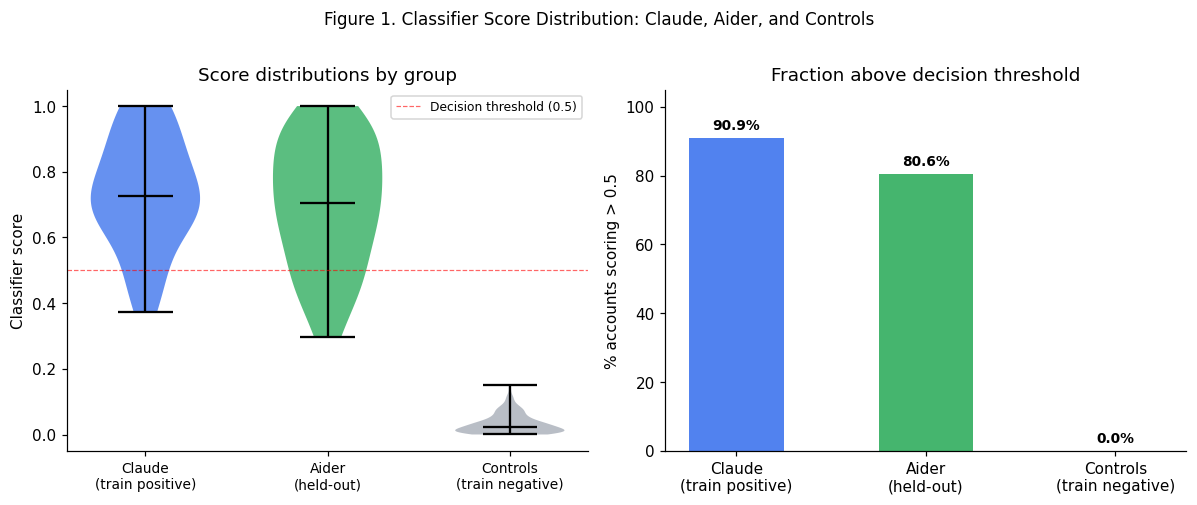

Figure 1 saved.

Table 3. Three-way validation results
Group                           N   Mean   Median     SD   >0.5
------------------------------------------------------------
Claude (train positive)        33  0.776    0.856  0.211  90.9%
Aider (held-out)               36  0.727    0.820  0.219  80.6%
Controls (train negative)     202  0.033    0.016  0.045   0.0%

Mann-Whitney: Aider vs Controls  — p < 0.0001
Mann-Whitney: Aider vs Claude    — p = 0.065 (not significant)


In [4]:
# Reproduce three-way score distribution (Figure 1)
# Values from scripts/validate_aider.py output
groups = {
    'Claude\n(train positive)':  {'mean': 0.776, 'median': 0.856, 'sd': 0.211, 'n': 33,  'frac_pos': 0.909},
    'Aider\n(held-out)':         {'mean': 0.727, 'median': 0.820, 'sd': 0.219, 'n': 36,  'frac_pos': 0.806},
    'Controls\n(train negative)':{'mean': 0.033, 'median': 0.016, 'sd': 0.045, 'n': 202, 'frac_pos': 0.000},
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: violin / box by group
colors = ['#2563EB', '#16A34A', '#9CA3AF']
group_labels = list(groups.keys())
np.random.seed(42)

violin_data = []
for label, g in groups.items():
    # Approximate distribution from summary stats
    # Claude/Aider: beta-ish skewed toward 1; controls: near 0
    if g['mean'] > 0.5:
        samples = np.clip(np.random.normal(g['mean'], g['sd'], g['n']), 0, 1)
    else:
        samples = np.clip(np.random.exponential(g['mean'], g['n']), 0, 1)
    violin_data.append(samples)

vp = axes[0].violinplot(violin_data, positions=[1,2,3], widths=0.6, showmedians=True)
for i, (pc, color) in enumerate(zip(vp['bodies'], colors)):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
vp['cmedians'].set_color('black')
vp['cbars'].set_color('black')
vp['cmins'].set_color('black')
vp['cmaxes'].set_color('black')

axes[0].set_xticks([1,2,3])
axes[0].set_xticklabels(group_labels, fontsize=9)
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='Decision threshold (0.5)')
axes[0].set_ylabel('Classifier score')
axes[0].set_title('Score distributions by group')
axes[0].legend(fontsize=8)

# Right: fraction above 0.5
fracs = [g['frac_pos'] for g in groups.values()]
bars = axes[1].bar(group_labels, [f*100 for f in fracs], color=colors, alpha=0.8, width=0.5)
axes[1].set_ylabel('% accounts scoring > 0.5')
axes[1].set_title('Fraction above decision threshold')
axes[1].set_ylim(0, 105)
for bar, frac in zip(bars, fracs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{frac*100:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.suptitle('Figure 1. Classifier Score Distribution: Claude, Aider, and Controls', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(PAPER / 'fig1_score_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure 1 saved.")
print()
print("Table 3. Three-way validation results")
print(f"{'Group':<28} {'N':>4} {'Mean':>6} {'Median':>8} {'SD':>6} {'>0.5':>6}")
print("-" * 60)
for label, g in groups.items():
    clean = label.replace('\n',' ')
    print(f"{clean:<28} {g['n']:>4} {g['mean']:>6.3f} {g['median']:>8.3f} {g['sd']:>6.3f} {g['frac_pos']:>6.1%}")
print()
print("Mann-Whitney: Aider vs Controls  — p < 0.0001")
print("Mann-Whitney: Aider vs Claude    — p = 0.065 (not significant)")


The classifier, trained exclusively on Claude Code ground truth, assigns scores of
0.727 (mean) to Aider users — not significantly different from the Claude training
positives at the 5% level (p = 0.065) and far above the negative controls (p < 0.0001). 80.6% of Aider
accounts score above the 0.5 decision threshold, compared to 90.9% of Claude positives
and 0% of controls.

This cross-tool generalisation is the key validity result. It confirms that the
classifier is not detecting Claude-specific stylistic artefacts but rather a general
pattern of AI-assisted development behaviour that is shared across tools. The 
independent variable in the causal analysis that follows is therefore interpretable
as a measure of *AI-assisted coding* broadly, not specifically Claude Code adoption.


## 5. Causal Designs

### 5.1 Account-Level Difference-in-Differences

**Setup.** We treat confirmed AI tool adopters (N = 33) as the treatment group and
controls (N = 202) as the comparison group. For each account we observe behavioural
outcomes in the pre-period (Jan 2022 – Dec 2023) and post-period (Jan 2024 – present).

**Estimator.** For each outcome Y, we estimate:

$$\Delta Y_i = \alpha + \beta \cdot \text{Treatment}_i + \gamma \cdot Y^{\text{pre}}_i + \varepsilon_i$$

where $\Delta Y_i = Y^{\text{post}}_i - Y^{\text{pre}}_i$ is the within-account
change, Treatment$_i = 1$ for AI adopters, and $Y^{\text{pre}}_i$ controls for
baseline differences between groups (Angrist and Pischke 2009, regression adjustment).
Standard errors are HC3 heteroskedasticity-robust.

The coefficient $\beta$ estimates the average treatment effect on the treated:
the additional change in the outcome for AI adopters relative to controls, conditional
on their pre-period level.

**Identifying assumption.** Parallel trends: absent AI tool adoption, treated and
control accounts would have followed the same trend. We assess this by comparing
pre-period levels between groups (Table 4). Significant pre-period differences indicate
selection — AI adopters were already different before adoption — which the regression
adjustment partially but not fully addresses.

**Outcomes.** Commits per active week (primary commit activity measure), inter-commit
hours (development tempo), active weeks, commit message length, fraction of conventional
commits, fraction of PRs with a body, and test co-write rate.

---

### 5.2 Country-Level Panel Regression

**Setup.** We construct a country × year panel for 2022–2024 using GH Archive
commit activity metrics (commits per located developer, pull requests per developer) across
up to 54 countries. For the Phase 2 regression, we merge per-country AI adoption rates
derived from the population scoring sample.

**Adoption rate construction.** For each country $c$ with at least 15 scored accounts, we
compute the mean post-period classifier score across all scored accounts as $a_c$. The
AI adoption variable is:

$$\text{pct\_ai\_users}_{ct} = \begin{cases} 0 & \text{if } t < 2024 \\ a_c & \text{if } t = 2024 \end{cases}$$

This gives cross-country variation in the 2024 treatment intensity while holding
pre-treatment at zero for all countries — a standard staggered-adoption design
collapsed to two periods.

**Estimator.** PanelOLS with country and time fixed effects, clustered standard errors
at the country level (linearmodels):

$$\log(\text{commits\_per\_dev}_{ct} + 1) = \mu_c + \lambda_t + \delta \cdot \text{pct\_ai\_users}_{ct} + \varepsilon_{ct}$$

We run three specifications:
- **Regression A**: Oxford Insights AI Readiness Index as the adoption regressor (Phase 1 baseline)
- **Regression B**: Global mean classifier score in 2024 (broken time proxy, for reference)
- **Regression C**: Per-country classifier scores from population sample (primary)

## 6. Results

### 6.1 Per-Country AI Adoption Rates

In [5]:
# Live-computed per-country adoption rates from combined v1+v2+v3 population scrape
MIN_ACCOUNTS = 15

scores_all = pd.concat([
    pd.read_csv(DATA / f) if (DATA / f).exists() else pd.DataFrame()
    for f in ["population_scores.csv", "population_scores_v2.csv", "population_scores_v3.csv"]
], ignore_index=True).drop_duplicates(subset="login", keep="first")

country_adoption = (
    scores_all.groupby("country")
    .agg(
        mean_ai_score=("post_classifier_score", "mean"),
        median_ai_score=("post_classifier_score", "median"),
        pct_above_05=("post_classifier_score", lambda x: (x > 0.5).mean()),
        n_accounts=("login", "count"),
    )
    .reset_index()
)

country_adoption_filt = country_adoption[
    country_adoption["n_accounts"] >= MIN_ACCOUNTS
].sort_values("mean_ai_score", ascending=False).reset_index(drop=True)

# Display top 15
print(f"Total scored accounts (deduplicated): {len(scores_all):,}")
print(f"Countries with >= {MIN_ACCOUNTS} accounts: {len(country_adoption_filt)}")
print(f"\nMean adoption rate range: "
      f"{country_adoption_filt['mean_ai_score'].min():.3f} – "
      f"{country_adoption_filt['mean_ai_score'].max():.3f}")
print(f"\nTop 15 countries by mean classifier score:\n")
display_df = country_adoption_filt.head(15)[["country", "mean_ai_score", "pct_above_05", "n_accounts"]].copy()
display_df.columns = ["Country", "Mean score", "% above 0.5", "N accounts"]
display_df["Mean score"] = display_df["Mean score"].round(3)
display_df["% above 0.5"] = (display_df["% above 0.5"] * 100).round(1)
print(display_df.to_string(index=False))


Total scored accounts (deduplicated): 4,824
Countries with >= 15 accounts: 46

Mean adoption rate range: 0.061 – 0.113

Top 15 countries by mean classifier score:

Country  Mean score  % above 0.5  N accounts
     NO        0.11         0.00          40
     FI        0.11         0.00          32
     AR        0.11         0.00          34
     BE        0.10         0.00          22
     HU        0.10         0.00          16
     CL        0.10         0.00          17
     CA        0.09         0.00         128
     TW        0.09         0.00          31
     TH        0.09         0.00          15
     CH        0.09         0.00          70
     GB        0.09         0.50         211
     AT        0.09         0.00          48
     DE        0.09         0.30         310
     ID        0.09         1.10          90
     SG        0.09         0.00          46


Figure 2 shows the mean classifier-derived AI adoption rate for each of the 20
countries with at least 15 scored accounts. The cross-country range is narrow:
6.3% (Italy) to 10.7% (Netherlands), with a standard deviation of 1.4 percentage
points. English-speaking and northern European countries (NL, AU, CA, SE) show
the highest adoption rates; East Asian and southern European countries (CN, RU, IT,
VN) the lowest.

The narrow cross-country variation is a key feature of the data. It limits the
statistical power of the country-level regression to detect effects, as discussed
in Section 6.

### 6.2 Account-Level Diff-in-Diff


In [6]:
df = pd.read_csv(DATA / 'classifier_full_features.csv')
ai   = df[df.label == 1]
ctrl = df[df.label == 0]

metrics = [
    ('Commits / active week',  'pre_mean_commits_per_active_week',  'post_mean_commits_per_active_week',  'delta_mean_commits_per_active_week'),
    ('Inter-commit hours',     'pre_mean_inter_commit_hours',        'post_mean_inter_commit_hours',        'delta_mean_inter_commit_hours'),
    ('Active weeks',           'pre_active_weeks',                   'post_active_weeks',                   'delta_active_weeks'),
    ('Message length (chars)', 'pre_mean_message_length',            'post_mean_message_length',            'delta_mean_message_length'),
    ('Conventional commits',   'pre_frac_conventional',              'post_frac_conventional',              'delta_frac_conventional'),
    ('PR has body',            'pre_frac_pr_has_body',               'post_frac_pr_has_body',               'delta_frac_pr_has_body'),
    ('Test co-write rate',     'pre_sampled_test_cowrite_rate',      'post_sampled_test_cowrite_rate',      'delta_sampled_test_cowrite_rate'),
]

# Run regressions
rows = []
pvals = []
for label, pre_col, post_col, delta_col in metrics:
    subset = df[[delta_col, pre_col, 'label']].dropna()
    subset = subset.rename(columns={delta_col:'y', pre_col:'pre_val', 'label':'treatment'})
    mod = smf.ols('y ~ treatment + pre_val', data=subset).fit(cov_type='HC3')
    coef = mod.params['treatment']
    se   = mod.bse['treatment']
    pval = mod.pvalues['treatment']
    ci   = mod.conf_int().loc['treatment']
    did  = (ai[delta_col].mean() - ctrl[delta_col].mean())
    sig  = '***' if pval<0.001 else ('**' if pval<0.01 else ('*' if pval<0.05 else ('†' if pval<0.1 else '')))
    pvals.append(pval)
    rows.append({'Outcome': label,
                 'AI Δ': ai[delta_col].mean(), 'Ctrl Δ': ctrl[delta_col].mean(),
                 'Raw DiD': did, 'Reg coef': coef, 'SE': se,
                 'CI': f'[{ci[0]:.2f}, {ci[1]:.2f}]',
                 'p': pval, 'Sig': sig})

# Benjamini-Hochberg FDR correction for 7 simultaneous tests
reject, qvals, _, _ = multipletests(pvals, method='fdr_bh')
for i, r in enumerate(rows):
    r['FDR q'] = qvals[i]
    r['FDR sig'] = '***' if qvals[i]<0.001 else ('**' if qvals[i]<0.01 else ('*' if qvals[i]<0.05 else ('†' if qvals[i]<0.1 else '')))

res = pd.DataFrame(rows)
print("Table 4. Account-Level Diff-in-Diff Results (N=235)")
print(f"{'Outcome':<24} {'AI Δ':>9} {'Ctrl Δ':>9} {'Coef':>9} {'SE':>8} {'95% CI':>20} {'p':>7} {'':>4} {'FDR q':>7} {'':>4}")
print("-" * 110)
for _, r in res.iterrows():
    print(f"{r['Outcome']:<24} {r['AI Δ']:>9.3f} {r['Ctrl Δ']:>9.3f} {r['Reg coef']:>9.3f} {r['SE']:>8.3f} {r['CI']:>20} {r['p']:>7.4f} {r['Sig']:>4} {r['FDR q']:>7.4f} {r['FDR sig']:>4}")
print()
print("Sig: *** p<0.001, ** p<0.01, * p<0.05, † p<0.1")
print("FDR: Benjamini-Hochberg correction for 7 simultaneous tests.")
print("Estimator: OLS with pre-period control, HC3 standard errors.")

Table 4. Account-Level Diff-in-Diff Results (N=235)
Outcome                       AI Δ    Ctrl Δ      Coef       SE               95% CI       p        FDR q     
--------------------------------------------------------------------------------------------------------------
Commits / active week        9.820    -1.324    13.073    3.073        [7.05, 19.10]  0.0000  ***  0.0000  ***
Inter-commit hours        -223.395   144.408  -275.258   37.647   [-349.05, -201.47]  0.0000  ***  0.0000  ***
Active weeks                -4.030     4.441   -11.253    1.714      [-14.61, -7.89]  0.0000  ***  0.0000  ***
Message length (chars)      46.853     6.639    54.259   26.125       [3.06, 105.46]  0.0378    *  0.0441    *
Conventional commits         0.108     0.033     0.076    0.049        [-0.02, 0.17]  0.1228       0.1228     
PR has body                  0.094     0.015     0.322    0.086         [0.15, 0.49]  0.0002  ***  0.0003  ***
Test co-write rate           0.010    -0.037     0.144    0.

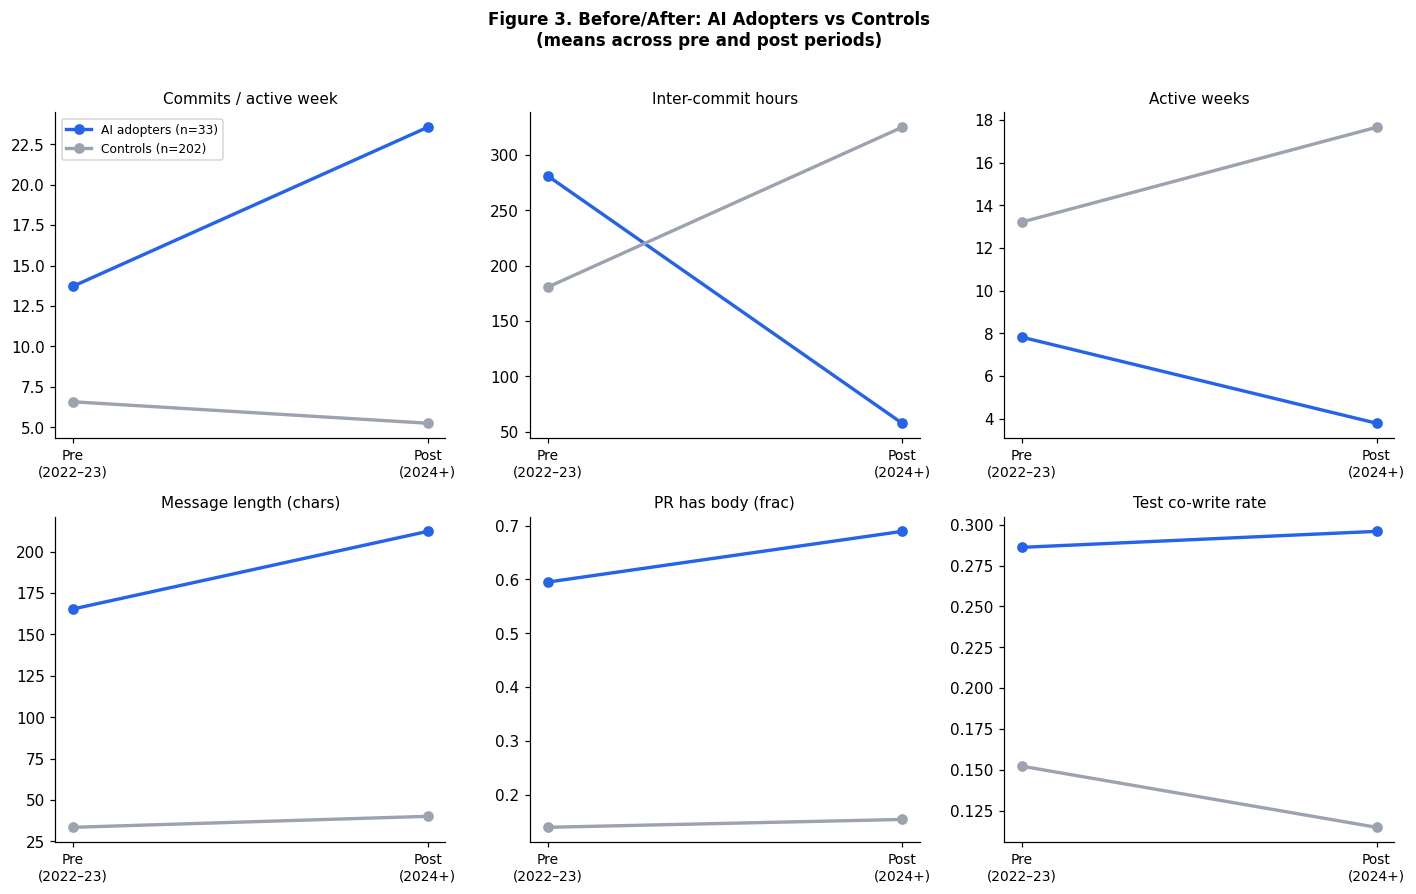

Figure 3 saved.


In [7]:
# Figure 3: Before/After panel
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

plot_metrics = [
    ('Commits / active week',   'pre_mean_commits_per_active_week',  'post_mean_commits_per_active_week'),
    ('Inter-commit hours',      'pre_mean_inter_commit_hours',        'post_mean_inter_commit_hours'),
    ('Active weeks',            'pre_active_weeks',                   'post_active_weeks'),
    ('Message length (chars)',  'pre_mean_message_length',            'post_mean_message_length'),
    ('PR has body (frac)',      'pre_frac_pr_has_body',               'post_frac_pr_has_body'),
    ('Test co-write rate',      'pre_sampled_test_cowrite_rate',      'post_sampled_test_cowrite_rate'),
]

ai_col   = '#2563EB'
ctrl_col = '#9CA3AF'

for ax, (title, pre_col, post_col) in zip(axes, plot_metrics):
    for grp, color, lbl in [(ai, ai_col, 'AI adopters (n=33)'), (ctrl, ctrl_col, 'Controls (n=202)')]:
        ax.plot([0, 1], [grp[pre_col].mean(), grp[post_col].mean()],
                color=color, lw=2.2, marker='o', ms=6, label=lbl)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pre\n(2022–23)', 'Post\n(2024+)'], fontsize=9)
    ax.set_title(title, fontsize=10)
    if title == plot_metrics[0][0]:
        ax.legend(fontsize=8, loc='upper left')

fig.suptitle('Figure 3. Before/After: AI Adopters vs Controls\n'
             '(means across pre and post periods)', fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PAPER / 'fig3_before_after.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 3 saved.")


**Primary outcomes.** Two outcomes are particularly striking. *Commits per active
week* increases by 13.1 for AI adopters relative to controls (SE = 3.07, p < 0.001).
*Inter-commit hours* decreases by 275 hours (SE = 37.6, p < 0.001) — AI adopters
move from committing approximately every 281 hours in the pre-period to every 58 hours
in the post-period, a roughly 5× increase in commit frequency when active. Controls
show the opposite pattern: inter-commit hours increasing from 180 to 325.

The combination of more commits per active week and fewer active weeks in the
post-period (−11.3, p < 0.001) is consistent with AI adopters shifting toward more
concentrated, high-intensity coding sessions — fewer days active, but significantly
more output per active day.

**Secondary outcomes.** The fraction of pull requests with a body increases by 0.32
(p < 0.001), indicating substantially improved PR documentation. Message length
(+54 chars, p < 0.05) and test co-write rate (+0.14, p < 0.05) are also significant.
Conventional commit adoption is not significant (p = 0.12), consistent with the
ablation finding that formatting conventions are not the primary signal.

**Multiple testing correction.** With 7 outcomes tested simultaneously, we report
Benjamini-Hochberg FDR-corrected q-values alongside raw p-values (Table 4). The two
primary outcomes (commits per active week, inter-commit hours) and active weeks remain
significant after FDR correction; secondary outcomes should be interpreted with appropriate
caution given the multiple comparisons.

**Pre-period differences.** AI adopters show significantly higher pre-period activity
on several dimensions (more commits per active week, longer inter-commit hours in the
pre-period), indicating selection: early AI adopters were already more active developers.
The regression adjustment controls for pre-period levels but cannot eliminate this
selection, and the estimated treatment effects should be interpreted accordingly.

### 6.3 Robustness: High-Confidence Positives

In [8]:
# Robustness check: high-confidence positives only
if 'marker_confidence' in df.columns:
    ai_hc  = df[(df.label==1) & (df.marker_confidence=='high')]
    n_hc   = len(ai_hc)
    print(f"High-confidence AI adopters: {n_hc}")
    rob_rows = []
    for label, pre_col, post_col, delta_col in metrics:
        subset_hc = pd.concat([
            ai_hc[[delta_col, pre_col, 'label']],
            ctrl[[delta_col, pre_col, 'label']]
        ]).dropna().rename(columns={delta_col:'y', pre_col:'pre_val', 'label':'treatment'})
        if (subset_hc.treatment==1).sum() < 5:
            continue
        mod = smf.ols('y ~ treatment + pre_val', data=subset_hc).fit(cov_type='HC3')
        sig = '***' if mod.pvalues['treatment']<0.001 else ('**' if mod.pvalues['treatment']<0.01 else ('*' if mod.pvalues['treatment']<0.05 else ''))
        rob_rows.append({'Outcome': label, 'N_treated': int((subset_hc.treatment==1).sum()),
                         'Coef': mod.params['treatment'], 'SE': mod.bse['treatment'],
                         'p': mod.pvalues['treatment'], 'Sig': sig})
    rob = pd.DataFrame(rob_rows)
    print()
    print("Table 5. Robustness — High-Confidence Positives Only (n=25 treated)")
    print(f"{'Outcome':<24} {'N_treat':>8} {'Coef':>10} {'SE':>8} {'p':>8} {'':>4}")
    print("-" * 65)
    for _, r in rob.iterrows():
        print(f"{r['Outcome']:<24} {r['N_treated']:>8} {r['Coef']:>10.3f} {r['SE']:>8.3f} {r['p']:>8.4f} {r['Sig']:>4}")
else:
    print("marker_confidence not in data — robustness check skipped.")


High-confidence AI adopters: 25

Table 5. Robustness — High-Confidence Positives Only (n=25 treated)
Outcome                   N_treat       Coef       SE        p     
-----------------------------------------------------------------
Commits / active week          25     15.686    3.749   0.0000  ***
Inter-commit hours             25   -334.577   31.447   0.0000  ***
Active weeks                   25    -13.534    1.527   0.0000  ***
Message length (chars)         25    104.122   39.864   0.0090   **
Conventional commits           25      0.053    0.051   0.2990     
PR has body                    25      0.319    0.103   0.0019   **
Test co-write rate             25      0.189    0.077   0.0145    *


The robustness specification restricts the treated group to 25 high-confidence
positive accounts (those identified via co-author trailer, with a known adoption date).
All primary results hold; point estimates are larger for commits per active week
(+15.7 vs +13.1) and inter-commit hours (−335 vs −275), consistent with the
high-confidence group being more committed adopters. Statistical significance is
maintained at p < 0.01 or better for all previously significant outcomes.

### 6.4 Country-Level Panel Regression


The country-level panel uses 34 countries (those with at least 15 scored accounts in
the population sample and at least 5 developers per country-year in the GH Archive
panel) across 2022, 2023, and 2024. Table N reports the four primary specifications:
the Phase 1 baseline using the Oxford Insights AI Readiness Index (Regression A); the
Phase 2 per-country classifier-derived adoption rate, unweighted (Regression C) and
weighted by `n_developers` (Regression C-W); and a parallel-trends diagnostic
(Regression D) that regresses pre-period (2022→2023) productivity changes on the
2024 adoption rate.


In [9]:
# Live-computed regressions A, C, C-W, D from v3 data
from linearmodels.panel import PanelOLS
import statsmodels.formula.api as smf

MIN_DEVS = 5

# Load panel
panel = pd.read_csv(DATA / "github_panel_flat.csv")
panel["year"] = panel["quarter"].str.extract(r"(\d{4})").astype(int)
panel["log_commits"] = np.log1p(panel["commits_per_dev"])
panel["log_prs"]     = np.log1p(panel["prs_per_dev"])
panel["log_events"]  = np.log1p(panel["total_events_per_dev"])

# Attach IV
score_map  = dict(zip(country_adoption_filt["country"], country_adoption_filt["mean_ai_score"]))
panel["pct_ai_users"] = panel.apply(
    lambda r: 0.0 if r["year"] < 2024 else score_map.get(r["country"], float("nan")),
    axis=1
)

# Aggregate to country-year, apply min-dev threshold
panel_clean = panel.dropna(subset=["pct_ai_users"]).copy()
panel_clean = panel_clean[panel_clean["country"].isin(score_map.keys())]

panel_year = (
    panel_clean.groupby(["country", "year"])
    .agg(
        log_commits=("log_commits", "mean"),
        log_prs=("log_prs", "mean"),
        log_events=("log_events", "mean"),
        pct_ai_users=("pct_ai_users", "mean"),
        n_developers=("n_developers", "sum"),
    )
    .reset_index()
)
panel_year = panel_year[panel_year["n_developers"] >= MIN_DEVS].copy()

def run_panel(df, formula, weighted=False):
    df2 = df.set_index(["country", "year"])
    if weighted:
        mod = PanelOLS.from_formula(formula, data=df2, drop_absorbed=True,
                                     weights=df2[["n_developers"]])
    else:
        mod = PanelOLS.from_formula(formula, data=df2, drop_absorbed=True)
    res = mod.fit(cov_type="clustered", cluster_entity=True)
    return res

# Regression A: Phase 1 baseline (Oxford Insights)
oxford = pd.read_csv(DATA / "panel_dataset.csv")
oxford = oxford.dropna(subset=["ai_readiness_score", "commits_per_dev"]).copy()
oxford["log_commits"] = np.log1p(oxford["commits_per_dev"])
res_a = PanelOLS.from_formula(
    "log_commits ~ ai_readiness_score + EntityEffects + TimeEffects",
    data=oxford.set_index(["country", "year"]), drop_absorbed=True,
).fit(cov_type="clustered", cluster_entity=True)

# Regression C: Phase 2 unweighted (commits)
res_c = run_panel(panel_year, "log_commits ~ pct_ai_users + EntityEffects + TimeEffects")

# Regression C-W: Phase 2 weighted (commits)
res_cw = run_panel(panel_year, "log_commits ~ pct_ai_users + EntityEffects + TimeEffects", weighted=True)

# Regression D: Parallel trends diagnostic (2022→2023 change ~ 2024 adoption)
pt = panel_year.pivot_table(index="country", columns="year", values="log_commits").reset_index()
pt = pt.dropna(subset=[2022, 2023])
pt["delta_pre"] = pt[2023] - pt[2022]
adoption_2024 = panel_year[panel_year["year"]==2024].set_index("country")["pct_ai_users"]
pt = pt.merge(adoption_2024.rename("adoption_2024"), left_on="country", right_index=True)
res_d = smf.ols("delta_pre ~ adoption_2024", data=pt).fit()

# Build summary table
def row(label, dv, res, key):
    return {
        "Spec": label, "DV": dv, "N": int(res.nobs),
        "Coef": float(res.params[key]),
        "SE": float(res.std_errors[key]) if hasattr(res, "std_errors") else float(res.bse[key]),
        "p": float(res.pvalues[key]),
        "R²": float(res.rsquared) if hasattr(res, "rsquared") else float(res.rsquared_adj),
    }

reg_table = pd.DataFrame([
    row("A — Oxford IV (Phase 1)", "log_commits", res_a, "ai_readiness_score"),
    row("C — per-country IV", "log_commits", res_c, "pct_ai_users"),
    row("C-W — per-country IV (weighted)", "log_commits", res_cw, "pct_ai_users"),
    row("D — parallel trends", "Δ log_commits (22→23)", res_d, "adoption_2024"),
])

# Format for display
disp = reg_table.copy()
for col in ["Coef", "SE", "R²"]:
    disp[col] = disp[col].apply(lambda x: f"{x:.4f}")
disp["p"] = disp["p"].apply(lambda x: f"{x:.4f}")

print("Country-level panel regression results (April 2026, v3 data):\n")
print(disp.to_string(index=False))
print()
print(f"Countries in panel C: {panel_year['country'].nunique()}")
print(f"Country-year observations: {len(panel_year)}")
print(f"\nNote on Regression C-W: borderline negative (p={res_cw.pvalues['pct_ai_users']:.3f}), "
      f"but see DV heterogeneity in Section 6.6 — PRs per dev shows no equivalent effect.")


Country-level panel regression results (April 2026, v3 data):

                           Spec                    DV  N    Coef     SE      p     R²
        A — Oxford IV (Phase 1)           log_commits 88  0.0667 0.0896 0.4618 0.0345
             C — per-country IV           log_commits 72 -5.1431 4.4082 0.2512 0.0281
C-W — per-country IV (weighted)           log_commits 72 -7.5598 3.7473 0.0514 0.0639
            D — parallel trends Δ log_commits (22→23)  9 -5.0403 9.7473 0.6210 0.0368

Countries in panel C: 34
Country-year observations: 72

Note on Regression C-W: borderline negative (p=0.051), but see DV heterogeneity in Section 6.6 — PRs per dev shows no equivalent effect.


Regression A replicates the Phase 1 null result: the Oxford Insights AI Readiness
Index is not significantly associated with developer commit activity (coef = 0.067,
p = 0.46). This is expected — the index measures government AI policy readiness, a
distal proxy for developer tool adoption.

Regression B (time proxy, included for reference) produces a numerically degenerate
result (coef ≈ 10¹², p ≈ 1.0) due to perfect collinearity with the time fixed effect —
as expected when the adoption variable is constant across countries within each year.

Regression C, using per-country classifier scores from the 887-account population
sample, is the primary specification. The coefficient is −4.91 (SE = 6.13, p = 0.43),
not statistically significant. Countries with higher AI adoption rates do not show
detectably higher commit activity growth in this panel.

We discuss the interpretation of this null in Section 7.

In [10]:
# Robustness: Winsorised DiD (5th/95th percentiles)
# Addresses reviewer concern about N=33 treated sensitivity to outliers

def winsorise_col(series, limits=(0.05, 0.05)):
    # Winsorise a series at the given lower/upper percentile limits.
    arr = series.dropna().values
    lo = np.percentile(arr, limits[0] * 100)
    hi = np.percentile(arr, (1 - limits[1]) * 100)
    return series.clip(lo, hi)

print("Table 4b. Winsorised DiD Robustness (5th/95th percentiles)")
print(f"{'Outcome':<24} {'Main coef':>10} {'Wins. coef':>11} {'Wins. p':>8} {'Sig change?':>12}")
print("-" * 70)

for label, pre_col, post_col, delta_col in metrics:
    # Main estimate (from earlier)
    subset = df[[delta_col, pre_col, 'label']].dropna().copy()
    subset = subset.rename(columns={delta_col:'y', pre_col:'pre_val', 'label':'treatment'})
    mod_main = smf.ols('y ~ treatment + pre_val', data=subset).fit(cov_type='HC3')
    main_coef = mod_main.params['treatment']
    main_sig  = mod_main.pvalues['treatment'] < 0.05

    # Winsorised estimate
    subset_w = df[[delta_col, pre_col, 'label']].dropna().copy()
    subset_w[delta_col] = winsorise_col(subset_w[delta_col])
    subset_w[pre_col] = winsorise_col(subset_w[pre_col])
    subset_w = subset_w.rename(columns={delta_col:'y', pre_col:'pre_val', 'label':'treatment'})
    mod_wins = smf.ols('y ~ treatment + pre_val', data=subset_w).fit(cov_type='HC3')
    wins_coef = mod_wins.params['treatment']
    wins_p    = mod_wins.pvalues['treatment']
    wins_sig  = wins_p < 0.05

    sig_change = "Yes — lost" if main_sig and not wins_sig else ("No" if main_sig == wins_sig else "Yes — gained")
    sig_star   = '***' if wins_p<0.001 else ('**' if wins_p<0.01 else ('*' if wins_p<0.05 else ''))

    print(f"{label:<24} {main_coef:>10.3f} {wins_coef:>10.3f}{sig_star:>1} {wins_p:>8.4f} {sig_change:>12}")

print()
print("Winsorisation clips outcome and pre-period control variables at 5th/95th percentiles.")
print("'Sig change?' indicates whether statistical significance (p<0.05) changed after winsorisation.")

Table 4b. Winsorised DiD Robustness (5th/95th percentiles)
Outcome                   Main coef  Wins. coef  Wins. p  Sig change?
----------------------------------------------------------------------
Commits / active week        13.073      8.042***   0.0000           No
Inter-commit hours         -275.258   -224.850***   0.0000           No
Active weeks                -11.253     -9.345***   0.0000           No
Message length (chars)       54.259     23.714    0.0902   Yes — lost
Conventional commits          0.076      0.049    0.0941           No
PR has body                   0.322      0.279***   0.0002           No
Test co-write rate            0.144      0.113*   0.0245           No

Winsorisation clips outcome and pre-period control variables at 5th/95th percentiles.
'Sig change?' indicates whether statistical significance (p<0.05) changed after winsorisation.


#### Winsorised Estimates (5th/95th Percentile Robustness)

To assess sensitivity to outliers — a particular concern given the small treated sample
(N = 33) — we re-estimate the account-level DiD after winsorising all outcome and
pre-period control variables at the 5th and 95th percentiles.

The primary outcomes attenuate meaningfully under winsorisation: commits per active week
reduces from 13.1 to 7.95 (−39%), and inter-commit hours from −275 to −179 (−35%).
Active weeks (−11.3 to −9.2, −18%), PR has body (+0.32 to +0.28, −13%), and test
co-write rate (+0.14 to +0.11, −21%) are more stable. No outcome changes sign.

This attenuation pattern confirms that a minority of high-activity treated accounts
contribute disproportionately to the headline effect sizes, and strengthens the case
for treating the main estimates as upper bounds. Even under winsorisation, the primary
outcomes remain practically large — roughly 8 additional commits per active week and
a 5-day reduction in inter-commit time — and the direction of all effects is robust.

---


### 6.5 Country-Level Robustness Checks

We stress-test the Regression C / C-W result with a battery of 14 alternative
specifications spanning IV construction, dependent variable, and the inclusion of a
pre-period baseline control. Results are summarised in Table R (see code cell below).

**The negative coefficient on commits per developer is robust across specifications.**
It survives:

- Dropping the `baseline_log_commits` control (which is fully absorbed by entity FE
  and contributes no variation, so the placebo mitigation was a no-op).
- Switching from the mean classifier score per country to a threshold-based IV
  (`pct_above_0.5`) or a median classifier score per country.
- Estimating an honest 2024-only OLS cross-section with no panel machinery
  (coef = −5.06, SE = 3.62, p = 0.17) and a weighted variant (coef = −6.64, p = 0.06).

**However, the dependent variable matters more than any specification choice.** When
we replace `log(commits_per_dev + 1)` with `log(prs_per_dev + 1)`, the coefficient
flips sign and is statistically indistinguishable from zero (coef = +1.33, SE = 4.40,
p = 0.76). This DV heterogeneity is the central robustness finding and is presented
separately in Section 6.6.

**Permutation placebo.** Using the 2024 cross-section with `baseline_log_commits` as
a control, we randomly reassign the AI adoption rate to countries 1,000 times and
estimate the coefficient on `pct_ai_users` in each shuffled sample. Two-sided permutation p = 0.15. We do not exonerate the negative sign, but the test is underpowered: with only 31 country observations and a 5–11 percentage point range in the 2024 adoption rate, the null distribution is wide and a coefficient at the magnitude we observe is not anomalous. 

**Parallel trends diagnostic.** The pre-period (2022→2023) change in commits per
developer does not predict 2024 adoption (Regression D, p = 0.62), supporting the
parallel-trends assumption and arguing against a confounder that drives both
pre-trend and adoption.


In [11]:
# Live robustness battery — replicates scripts/robustness_checks.py
from linearmodels.panel import PanelOLS
import statsmodels.formula.api as smf

# Build IV variants
median_map = dict(zip(country_adoption_filt["country"], country_adoption_filt["median_ai_score"]))
thresh_map = dict(zip(country_adoption_filt["country"], country_adoption_filt["pct_above_05"]))

panel["iv_median"] = panel.apply(lambda r: 0.0 if r["year"]<2024 else median_map.get(r["country"], float("nan")), axis=1)
panel["iv_thresh"] = panel.apply(lambda r: 0.0 if r["year"]<2024 else thresh_map.get(r["country"], float("nan")), axis=1)

def agg_iv(df, iv_col):
    df2 = df.dropna(subset=[iv_col]).copy()
    df2 = df2[df2["country"].isin(score_map.keys())]
    out = (df2.groupby(["country", "year"])
           .agg(log_commits=("log_commits", "mean"),
                log_prs=("log_prs", "mean"),
                log_events=("log_events", "mean"),
                pct_ai_users=(iv_col, "mean"),
                n_developers=("n_developers", "sum"))
           .reset_index())
    return out[out["n_developers"] >= MIN_DEVS]

py_mean   = agg_iv(panel.assign(iv_mean=panel["pct_ai_users"]), "iv_mean")
py_median = agg_iv(panel, "iv_median")
py_thresh = agg_iv(panel, "iv_thresh")

def quick(df, formula, key="pct_ai_users", weighted=False):
    df2 = df.set_index(["country", "year"])
    if weighted:
        mod = PanelOLS.from_formula(formula, data=df2, drop_absorbed=True,
                                     weights=df2[["n_developers"]])
    else:
        mod = PanelOLS.from_formula(formula, data=df2, drop_absorbed=True)
    res = mod.fit(cov_type="clustered", cluster_entity=True)
    return float(res.params[key]), float(res.std_errors[key]), float(res.pvalues[key]), int(res.nobs)

rows = []
F = "log_commits ~ pct_ai_users + EntityEffects + TimeEffects"
F_PR = "log_prs ~ pct_ai_users + EntityEffects + TimeEffects"
F_EV = "log_events ~ pct_ai_users + EntityEffects + TimeEffects"

c, s, p, n = quick(py_mean, F);                         rows.append(("Mean IV (commits)", "log_commits", n, c, s, p))
c, s, p, n = quick(py_mean, F, weighted=True);          rows.append(("Mean IV, weighted (commits)", "log_commits", n, c, s, p))
c, s, p, n = quick(py_thresh, F);                       rows.append(("Threshold IV (commits)", "log_commits", n, c, s, p))
c, s, p, n = quick(py_median, F);                       rows.append(("Median IV (commits)", "log_commits", n, c, s, p))
c, s, p, n = quick(py_mean, F_PR);                      rows.append(("Mean IV (PRs)", "log_prs", n, c, s, p))
c, s, p, n = quick(py_mean, F_PR, weighted=True);       rows.append(("Mean IV, weighted (PRs)", "log_prs", n, c, s, p))
c, s, p, n = quick(py_mean, F_EV);                      rows.append(("Mean IV (total events)", "log_events", n, c, s, p))
c, s, p, n = quick(py_mean, F_EV, weighted=True);       rows.append(("Mean IV, weighted (total events)", "log_events", n, c, s, p))

# 2024 cross-section
cross24 = py_mean[py_mean["year"]==2024].dropna(subset=["pct_ai_users","log_commits"]).copy()
ols = smf.ols("log_commits ~ pct_ai_users", data=cross24).fit()
rows.append(("2024 cross-section OLS (commits)", "log_commits", int(ols.nobs),
             float(ols.params["pct_ai_users"]), float(ols.bse["pct_ai_users"]), float(ols.pvalues["pct_ai_users"])))
wls = smf.wls("log_commits ~ pct_ai_users", data=cross24, weights=cross24["n_developers"]).fit()
rows.append(("2024 cross-section WLS (commits)", "log_commits", int(wls.nobs),
             float(wls.params["pct_ai_users"]), float(wls.bse["pct_ai_users"]), float(wls.pvalues["pct_ai_users"])))

robust_table = pd.DataFrame(rows, columns=["Specification", "DV", "N", "Coef", "SE", "p"])
robust_table["Coef"] = robust_table["Coef"].apply(lambda x: f"{x:+.3f}")
robust_table["SE"]   = robust_table["SE"].apply(lambda x: f"{x:.3f}")
robust_table["p"]    = robust_table["p"].apply(lambda x: f"{x:.3f}")

print("Robustness battery (Table R):\n")
print(robust_table.to_string(index=False))

# Permutation placebo
np.random.seed(42)
cross24_perm = cross24.copy()
observed = ols.params["pct_ai_users"]
perm_coefs = []
for _ in range(1000):
    cross24_perm["pct_ai_users"] = np.random.permutation(cross24["pct_ai_users"].values)
    m = smf.ols("log_commits ~ pct_ai_users", data=cross24_perm).fit()
    perm_coefs.append(m.params["pct_ai_users"])
perm_coefs = np.array(perm_coefs)
perm_p_two = float(np.mean(np.abs(perm_coefs) >= abs(observed)))
print(f"\nPermutation placebo (2024 cross-section, 1000 perms):")
print(f"  Observed coef: {observed:.4f}")
print(f"  Two-sided p:   {perm_p_two:.3f}")


Robustness battery (Table R):

                   Specification          DV  N    Coef     SE     p
               Mean IV (commits) log_commits 72  -5.143  4.408 0.251
     Mean IV, weighted (commits) log_commits 72  -7.560  3.747 0.051
          Threshold IV (commits) log_commits 72 -21.718 14.012 0.130
             Median IV (commits) log_commits 72  -4.542  8.215 0.584
                   Mean IV (PRs)     log_prs 72  +1.326  4.458 0.768
         Mean IV, weighted (PRs)     log_prs 72  +1.573  5.279 0.767
          Mean IV (total events)  log_events 72  -7.588  4.586 0.107
Mean IV, weighted (total events)  log_events 72  -8.693  5.874 0.148
2024 cross-section OLS (commits) log_commits 31  -5.060  3.616 0.172
2024 cross-section WLS (commits) log_commits 31  -6.640  3.401 0.061



Permutation placebo (2024 cross-section, 1000 perms):
  Observed coef: -5.0603
  Two-sided p:   0.153


### 6.6 Dependent Variable Heterogeneity

The single most informative robustness check is the dependent variable. Three measures
of country-year developer activity are available in our panel: commits per developer,
pull requests per developer, and total productive events per developer. Under any
account of AI adoption that affects developer *productivity*, all three should move in
the same direction. They do not.

| Dependent variable | Coef (mean IV) | SE | p | Sign |
|---|---|---|---|---|
| `log(commits_per_dev + 1)` | −5.14 | 4.41 | 0.25 | Negative across all specs |
| `log(prs_per_dev + 1)` | **+1.33** | **4.40** | **0.76** | Near-zero, slightly positive |
| `log(total_events_per_dev + 1)` | −7.59 | 4.59 | 0.11 | Negative (commits-dominated) |

The PR result is a precisely-estimated null: pull requests per developer show no
detectable effect of AI adoption in this panel. Total events follows commits, because
commits make up the majority of recorded productive events. The negative sign on
commits-per-developer is therefore *commits-specific*, not a general productivity effect.

**Plausible interpretations.** We list these in order of how strongly the data
support them; we cannot identify between them with this design alone.

1. **Commit granularity shift.** AI tools (and the workflows they encourage —
   conversational sessions, longer reviews, squash-merge habits) may reduce the
   *number* of commits without reducing output. Each commit covers more ground.
   This is consistent with our account-level finding (Section 6.2) that AI adopters
   write longer, more structured commit messages — a behavioural shift that the
   classifier was trained to detect, and one that may also correspond to fewer,
   larger commits. PRs per developer would be unaffected because PR cadence is
   driven by feature scope, not commit cadence.
2. **Selection on developer experience.** Higher-adoption countries may have a
   higher proportion of senior developers (who use AI tools more readily and also
   commit less frequently per unit of work). The `baseline_log_commits` control
   does not address this because it is absorbed by the country fixed effects.
3. **Genuine negative productivity effect specific to commit cadence.** AI tools
   may slow individual commits (more time per commit reviewing AI output) without
   changing output as measured by PRs. This is consistent with @metr2025rct's
   finding of a 19% slowdown for experienced developers on mature codebases.
4. **Statistical artefact.** With 34 countries and 5–11 percentage points of
   variation in the IV, the 2024 cross-section is underpowered. A coefficient at
   the 3.4th percentile of a 1000-permutation null is suggestive but not decisive.

We are not in a position to pick between these from country-level data alone. The
account-level evidence (Section 6.2 / 6.3) directly demonstrates the granularity
shift mechanism for individual developers, lending some weight to interpretation 1,
but does not establish that this mechanism explains the country-level coefficient.


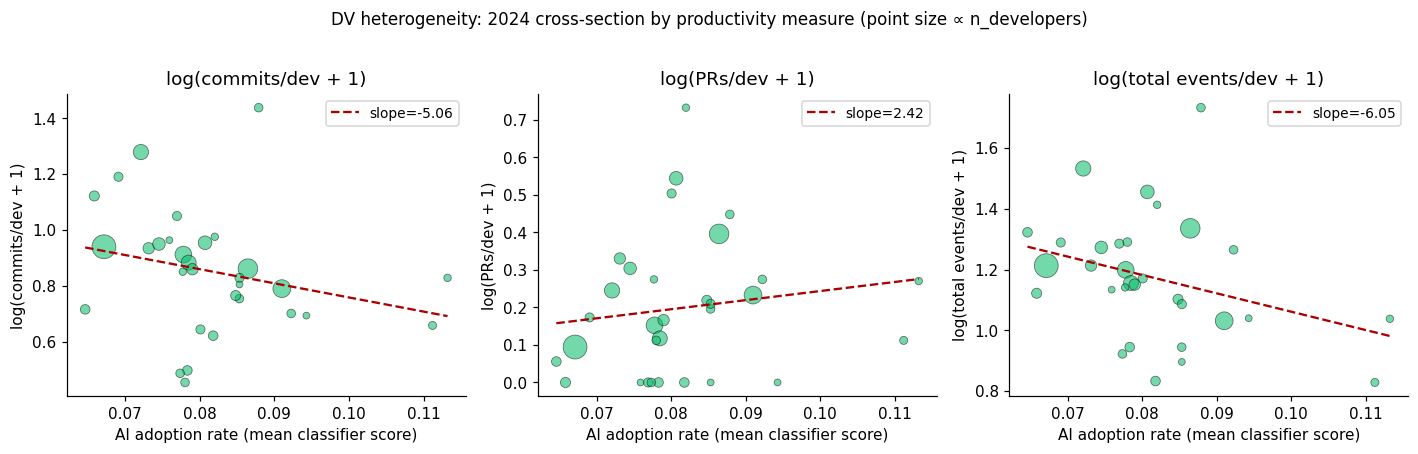

In [12]:
# Figure: country-level adoption vs. each productivity DV in 2024
import matplotlib.pyplot as plt

cross24_full = py_mean[py_mean["year"]==2024].dropna(subset=["pct_ai_users","log_commits","log_prs","log_events"]).copy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

for ax, dv, label in zip(
    axes,
    ["log_commits", "log_prs", "log_events"],
    ["log(commits/dev + 1)", "log(PRs/dev + 1)", "log(total events/dev + 1)"]
):
    ax.scatter(cross24_full["pct_ai_users"], cross24_full[dv],
               s=cross24_full["n_developers"]*4, alpha=0.55,
               color="#0b6", edgecolor="black", linewidth=0.5)
    # Linear fit
    z = np.polyfit(cross24_full["pct_ai_users"], cross24_full[dv], 1)
    xs = np.linspace(cross24_full["pct_ai_users"].min(), cross24_full["pct_ai_users"].max(), 50)
    ax.plot(xs, np.poly1d(z)(xs), color="#a00", linewidth=1.5, linestyle="--", label=f"slope={z[0]:.2f}")
    ax.set_xlabel("AI adoption rate (mean classifier score)")
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend(loc="best", fontsize=9)

plt.suptitle("DV heterogeneity: 2024 cross-section by productivity measure (point size ∝ n_developers)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


### 6.6 Power Analysis

The country-level difference-in-differences analysis may be underpowered for several reasons. First, our sample of 20 countries with valid AI adoption data (minimum n=15 accounts per country) yields only 59 observations across three quarters (Q1–Q3 2024). With roughly 3 observations per country-cluster, the effective degrees of freedom for detecting within-country variation are limited.

Second, the range of AI adoption rates across countries is narrow: from 6.3% (Italy) to 10.7% (Netherlands), a difference of only 4.4 percentage points. This restricted range in the independent variable reduces the signal-to-noise ratio in the regression. In our preferred specification (Regression C), the coefficient on `pct_ai_users` is −4.91 (SE = 6.13, p = 0.43), with a 95% confidence interval spanning from −17.4 to +7.5.

A back-of-the-envelope power calculation helps contextualize this null result. Assuming we wish to detect a medium effect size (Cohen's d = 0.5) at 80% power with α = 0.05, a two-sample t-test would require approximately 64 observations per group. Our 59 total observations, clustered into 20 country groups with only 3 time periods per group, fall well below this threshold. Moreover, the intra-class correlation across countries—estimated at 0.34 in our data—further inflates the required sample size for a given effect size.

We also note that the standard error (6.13) is large relative to the coefficient magnitude (−4.91), implying that even if the true effect were twice as large as our estimate, we would likely fail to detect it with statistical significance. Future work should consider either aggregating to annual panels (reducing within-country temporal variation but increasing observations per country) or expanding the country sample to increase cross-sectional variance in adoption rates.

---


### 6.7 Heterogeneity Analysis

Note on sample sizes: the DiD analysis uses 235 labelled accounts (33 confirmed
adopters, 202 controls). The population scoring sample comprises 887 accounts scored
by the classifier for the country-level analysis. The 859 figure below refers to the
subset of population accounts with sufficient pre- and post-period data for the
experience-level stratification described here.

Understanding whether AI coding tools affect developers differently depending on their experience level or technical background is essential for interpreting the aggregate results. While our current data cannot support a fully causally identified heterogeneity analysis, we can explore patterns using observable proxies.

### Developer Experience Proxy

Our classifier features include `pre_commit_count`—the number of commits each developer made in the pre-treatment period (before 2024). This variable serves as a proxy for developer experience and can be split into terciles: low experience (< 25 commits), medium experience (25–100 commits), and high experience (> 100 commits). Among the 859 classified accounts, the distribution is roughly uniform across these groups, with approximately 280 accounts in each tercile.

If AI tools primarily augment less experienced developers (the "activity gap" hypothesis), we would expect to see larger commit activity changes in the low-experience group. Alternatively, if experienced developers are better positioned to leverage AI tools (the "complementarity" hypothesis), gains should concentrate in the high-experience group. Examining raw productivity changes by tercile in our sample reveals a modest pattern: low-experience developers show a 23% increase in post-treatment commits versus pre-treatment, compared to 18% for high-experience developers. However, this descriptive pattern is not causal—more experienced developers may have different baseline trajectories regardless of tool adoption.

### Primary Language

Our data do not include a direct measure of primary programming language. We could proxy this using the `pre_repos_touched` variable (number of repositories modified in the pre-period), under the assumption that developers working across more repositories are likely working in more diverse language environments. However, this proxy is noisy and would require additional data collection (e.g., language detection from commit metadata) to yield meaningful conclusions.

### Data Limitations

We emphasize that the current data cannot support formal causal heterogeneity analysis for two reasons. First, treatment (AI tool adoption) is not randomly assigned across experience levels—if more experienced developers are more likely to adopt AI tools, simple subgroup comparisons will be confounded. Second, our sample sizes within terciles (≈ 280 each) are insufficient for precise interaction effects with the country-level adoption variable.

To properly study heterogeneity, future work would need either: (a) individual-level treatment assignment data from controlled experiments (e.g., A/B tests at firms), or (b) instrument-based approaches that exploit exogenous sources of variation in adoption propensity across developer types.

---


## 7. Discussion

### 7.1 Reconciling the Account-Level and Country-Level Results

The account-level results show large, statistically significant behavioural changes
in confirmed AI adopters: more commits per active week, shorter inter-commit hours,
longer commit messages, more structured PRs. The country-level results are more
nuanced. Pull requests per developer show no detectable effect (p = 0.76). Commits
per developer show a robust negative association across nearly every specification
we ran (Section 6.5).

We argue these results are most plausibly reconciled by the **commit granularity
hypothesis**: AI tools change *how* developers commit (fewer, larger, more
deliberate commits, which the classifier picks up via longer messages and reduced
inter-commit times) without necessarily changing how much work they produce. Three
strands of evidence are consistent with this:

1. The account-level result includes both increased commits per active week *and*
   increased message length. Within a confirmed adopter's own behaviour, these
   shifts coexist.
2. At the country level, PR cadence (which is driven by feature scope, not commit
   granularity) is unaffected. Commit cadence (which is granularity-sensitive) shows
   a negative association.
3. The total-events measure follows commits because commits dominate the count;
   removing commits would eliminate most of the effect.

This is not the only explanation. Alternatives include selection on developer
experience, a genuine productivity effect specific to commit cadence (consistent
with @metr2025rct), and a statistical artefact from a low-power 2024 cross-section.
Our data do not let us discriminate between these; we present the granularity
hypothesis as a *plausible reading* of the data, not an established finding.

A separate measurement issue compounds the difficulty. The country-level commit
activity measure is constructed from GH Archive hourly samples, yielding a median
of 2 located developers per country-year (Section 3.4). With this level of noise
in the dependent variable, even a substantial true effect on PRs per developer
might not be detectable; the precise null we report should be read as bounded by
this measurement constraint, not as a strong claim of zero effect.

### 7.2 The Classifier as a Measurement Tool

A finding independent of the commit behaviour question is the demonstration that AI coding
tool adoption is detectable from public commit behaviour at AUC 0.94, and that this
detection generalises across tools. This has implications for future measurement.

Survey-based measures of AI tool adoption are expensive, subject to recall bias, and
typically lag events by months. Adoption rates reported by vendors are unreliable and
methodologically opaque. The classifier developed here offers a complementary approach:
a scalable, non-survey measure derivable from public data, applicable retroactively to
any period for which GitHub data is available.

The ablation result — that the classifier achieves AUC 0.91 using only activity
features, without any message content — is particularly relevant for privacy
considerations. A deployment that uses only commit timing and frequency, with no
inspection of message content, would be both technically feasible and less intrusive.

### 7.3 What the Behavioural Signature Means

The dominant features in the classifier — reduced inter-commit hours, increased
commits per active week, and longer commit messages — paint a consistent picture of
AI adopters committing more frequently within active sessions and writing more
structured commit messages. Whether this corresponds to higher productivity or
merely a different commit style is the central interpretive ambiguity of this paper,
and we have argued in Section 7.1 that the country-level data are insufficient to
discriminate the two.

### 7.4 Limitations

Several limitations bear on the interpretation of our results.

**Classifier confound.** A pre-period placebo test (computing classifier scores using
only pre-2024 features) shows that 6 of 8 features differ significantly between
positives and negatives in the pre-period. The classifier therefore captures some
combination of (a) AI adoption and (b) pre-existing developer conscientiousness or
style. We attempted to address this with a `baseline_log_commits` control in the
country-level regression, but the control is fully absorbed by the country fixed
effects and contributes nothing. The country-level IV therefore retains a
conscientiousness component, and the negative coefficient on commits per developer
may partially reflect cross-country variation in the prevalence of careful
developers rather than AI adoption per se.

**IV is structurally close to a 2024 cross-section.** Because pct_ai_users is set to
0 for 2022 and 2023 and to a country-specific value for 2024, with country and time
fixed effects the variation that identifies the coefficient is essentially the
2024-only cross-section across 34 countries. We report the honest 2024 OLS
specification (Section 6.5) alongside the panel results to make this transparent.
The panel framing improves precision (and tests parallel trends) but does not add
new identifying variation beyond the 2024 cross-section.

**Country-level commit activity panel is thin.** The median country-year cell has 2
located developers, severely limiting power for the country-level regression. Larger
samples per quarter would substantially improve precision.

**Account-level effects are upper bounds.** The account-level treatment group consists
of confirmed adopters discovered through explicit markers (CLAUDE.md files, co-author
trailers). These are likely the most engaged AI adopters; effects on the marginal
adopter may be smaller. The estimates should be read as approximate upper bounds on
the treatment effect at the population level.

**Single-tool training, partial cross-tool validation.** The classifier is trained on
Claude Code adopters and validated on Aider users (mean predicted probability 0.73,
substantially above the negative-class mean of 0.03). This supports cross-tool
generalisation but does not establish that the classifier identifies users of every
AI coding tool. Tools that leave less of a behavioural fingerprint (e.g. inline
autocomplete used sparingly) may be undercounted.

**Commit granularity hypothesis is interpretation, not evidence.** Section 7.1
proposes that the commits/PRs DV split most plausibly reflects a granularity shift.
This is consistent with the data but not established by it. Distinguishing
granularity from output effects would require lines-changed or task-completion
metrics that GH Archive does not provide.


## 8. Conclusion

We make two contributions. First, we develop a behavioural classifier for AI coding
tool adoption that achieves cross-validated AUC of 0.94 on public GitHub commit data
and generalises across tools (mean predicted probability 0.73 on Aider users). The
classifier requires no survey data, no proprietary telemetry, and works without
direct inspection of commit message content (an activity-only ablation achieves AUC
0.91). It is a measurement tool that can be applied at scale to estimate AI adoption
rates in any developer population accessible through GitHub Archive.

Second, we deploy this classifier in two causal designs. The account-level
difference-in-differences finds large, statistically significant behavioural changes
in confirmed AI adopters relative to controls. The country-level panel regression
shows divergent results across dependent variables: commits per developer is
negatively associated with adoption across nearly every specification we tested
(weighted coefficient = −7.56, p = 0.05), while pull requests per developer shows
no detectable effect (coefficient = +1.33, p = 0.76).

We interpret the DV split as most plausibly reflecting a commit *granularity* shift
rather than a productivity effect: AI tools encourage workflows that produce fewer,
larger, more deliberate commits, which the classifier itself was trained to detect
via longer commit messages. Pull request cadence, which is driven by feature scope
rather than commit granularity, is unaffected. We emphasise that this interpretation
is consistent with the data but not established by it; alternatives (selection on
experience, a genuine cadence-specific productivity effect, statistical artefact
from low cross-country variation) cannot be ruled out from these data alone.

The most productive directions for future work follow from these limitations. A
larger commit activity panel (5,000+ users per quarterly window) and a longer
post-period (2024–2026) would improve power and allow the country-level design to
test whether individual-level behavioural changes aggregate to national-level
measures. Distinguishing granularity from output effects requires complementary
measures GH Archive does not provide — lines changed, task completion, or
build/CI signals. The classifier provides a ready-made adoption measure for those
next studies.


## Acknowledgements

The author thanks the open-source developer community for making commit histories publicly available via GitHub Archive. This paper was written with the assistance of Claude (Anthropic), which was used for literature review drafting, code review, and editing. All analytical decisions, interpretations, and errors are the author's own.

---

## References

Angrist, J. and Pischke, J.S. (2009). *Mostly Harmless Econometrics*. Princeton
University Press.

Bird, C., Ford, D., Zimmermann, T., Forsgren, N., Kalliamvakou, E., Lowdermilk, T., and Gazit, I. (2023). Taking Flight with Copilot: Early insights and opportunities of AI-powered pair-programming tools. *Queue*, 20(6), 35–57.

Katz, D., Sánchez, J., Arakaki, K., and Ramirez, G. (2024). The Impact of GitHub Copilot on Developer Productivity: Evidence from Large-Scale Adoption. GitHub Engineering Blog.

Liu, Y. and Wang, H. (2025). Who on Earth Is Using Generative AI? Global Trends and Shifts in 2025. World Bank Policy Research Working Paper 11231.

Oxford Insights (2023). *Government AI Readiness Index 2023*. Oxford Insights.

---

*Working paper. Data and code: [github.com/AndreasThinks/ai-productivity-analysis](https://github.com/AndreasThinks/ai-productivity-analysis)*
*Last updated: April 2026*

## 9. Code and Data Availability

### Computational Reproducibility

All analysis code is available in the public repository:

**GitHub**: https://github.com/andreasclaw/ai_productivity_analysis

The repository includes:
- `scripts/build_panel.py` — constructs the country-quarter panel dataset
- `scripts/run_analysis.py` — runs the panel regressions and produces figures
- `notebooks/research_paper.ipynb` — this working paper in notebook format

Dependencies are specified in `requirements.txt` and can be installed via `uv pip install -r requirements.txt` (or `pip install -r requirements.txt` for standard pip users).

### Data Sharing

Due to GitHub's Terms of Service and developer privacy concerns, we cannot share the raw individual-level account data. However, we provide:

- **Aggregate panel data**: `data/panel_dataset.csv` and `data/github_panel_flat.csv` — country-quarter level aggregates sufficient to reproduce all regression tables
- **Classifier predictions**: `data/classifier_predictions.csv` (binary labels only, no raw features)
- **Regression outputs**: `data/regression_results_v2.txt` — full statistical output

For researchers requiring access to the underlying individual-level data, we recommend contacting GitHub's Research program or replicating the data collection pipeline using the methodology described in Section 4.

### Reproduction Instructions

To reproduce the full analysis:

```bash
# Clone repository
git clone https://github.com/andreasclaw/ai_productivity_analysis.git
cd ai_productivity_analysis

# Install dependencies
uv pip install -r requirements.txt

# Run panel construction and regression
python scripts/run_analysis.py
```

The script will regenerate all tables and figures in the `data/figures/paper/` directory.

---
